# Module 9: Feature Extraction and Machine Learning
This is where signal processing meets AI/ML. You’ll learn to:
- Extract meaningful features from signals (time + frequency domain)
- Build ML models (e.g., SVM, Random Forest, or a simple neural net)
- Apply them to tasks like classification (e.g., heartbeat normal/abnormal)

In [49]:
# install necessary packages ...only needed if generating synthetic dataset.
!pip install neurokit2
!pip install PyWavelets


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [14]:
import numpy as np
import pandas as pd

file = "data_synthetic_ecg_signals.csv"

In [30]:
# # Part 1: Prepare the Data
# # We'll simulate or load labeled ECG-like data to demonstrate classification.

# # Generate Synthetic ECG with Labels

# import neurokit2 as nk # pip install neurokit2

# # Simulate 100 ECG signals: 50 normal, 50 abnormal (simulated by adding noise)
# X = []
# y = []

# for i in range(50):
#     ecg = nk.ecg_simulate(duration=10, noise=0.01, sampling_rate=200)
#     X.append(ecg)
#     y.append(0)  # Normal

# for i in range(50):
#     ecg = nk.ecg_simulate(duration=10, noise=0.3, sampling_rate=200)
#     X.append(ecg)
#     y.append(1)  # Abnormal

# X = np.array(X)
# y = np.array(y)

# ################################
# # Convert X (list of arrays) to 2D NumPy array
# df = pd.DataFrame(np.array(X))
# df["label"] = y  # Add labels column at the end
# df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True) # Lets shuffle before saving
# df_shuffled.to_csv(file, index=False)

In [53]:
# Load ECG data from CSV
df_loaded = pd.read_csv(file)
print(df_loaded.head(10))
print("##################")
print(df.info())
print("##################")
print(df.describe())

          0         1         2         3         4         5         6  \
0  1.087617  1.003138  0.791223  0.508845  0.215157 -0.035336 -0.217929   
1  0.957005  0.875234  0.668979  0.391330  0.097508 -0.160022 -0.354759   
2  0.808223  0.731017  0.536720  0.275795  0.000794 -0.237836 -0.413634   
3  1.102341  1.022496  0.820910  0.548896  0.259888  0.005260 -0.187735   
4  1.084120  1.006049  0.808580  0.541149  0.255284  0.001027 -0.193741   
5  1.096075  1.014815  0.810134  0.535162  0.245166 -0.007354 -0.195981   
6  1.103528  1.021234  0.813985  0.535656  0.242289 -0.012945 -0.203411   
7  0.876855  0.795572  0.590507  0.314110  0.020993 -0.236349 -0.430125   
8  1.092295  1.012712  0.812185  0.542616  0.258006  0.009733 -0.176175   
9  1.077906  0.997533  0.795110  0.523248  0.236670 -0.012718 -0.198932   

          7         8         9  ...      1991      1992      1993      1994  \
0 -0.325948 -0.363424 -0.345098  ...  0.040237  0.050285  0.059691  0.068297   
1 -0.478863 -0

In [54]:
# Separate features and labels
X = df_loaded.drop("label", axis=1).values  # shape: (n_samples, n_timepoints)
y = df_loaded["label"].values

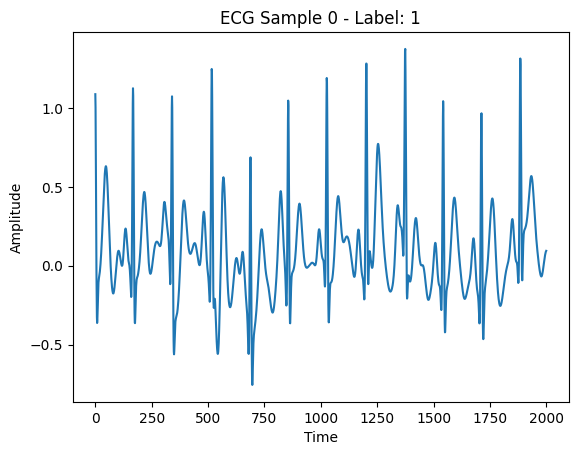

In [55]:
# Lets visualize 1 signal
import matplotlib.pyplot as plt

plt.plot(X[0])
plt.title(f"ECG Sample 0 - Label: {y[0]}")
plt.xlabel("Time")
plt.ylabel("Amplitude")
plt.show()

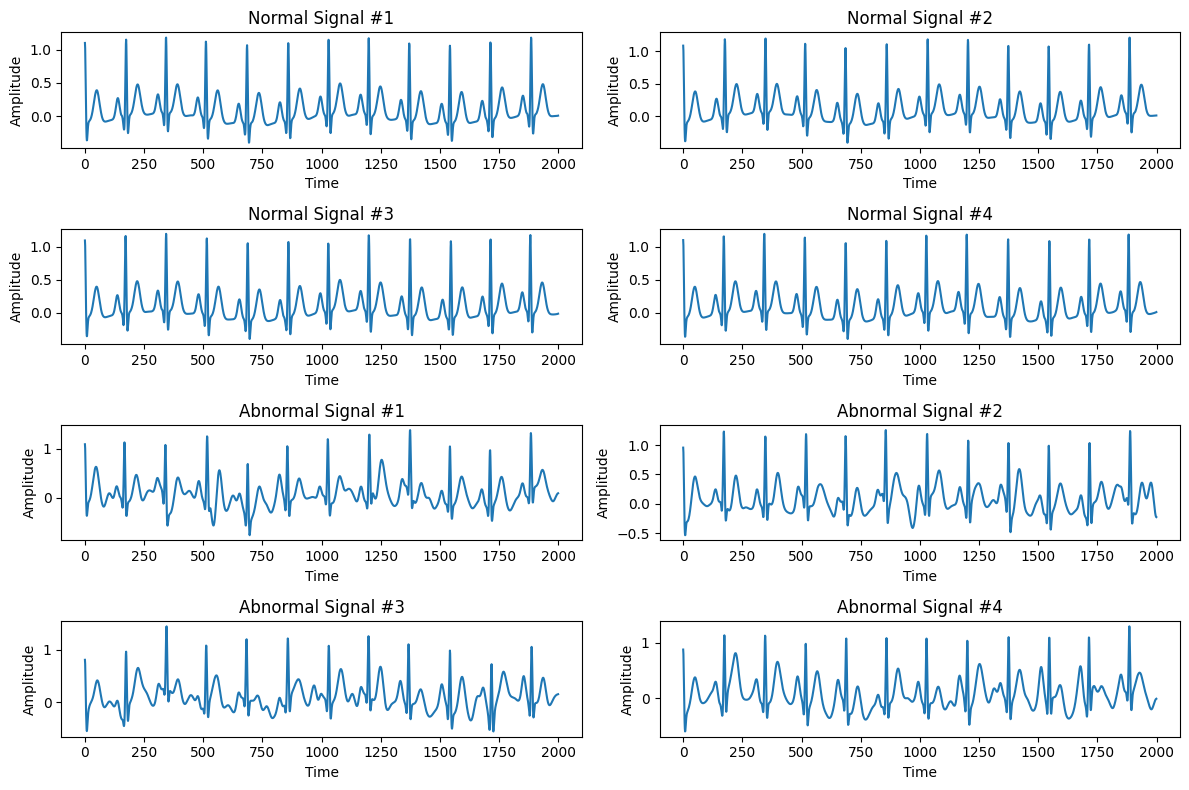

In [56]:
# I want to plot 4 normal and 4 abnormal signals
import matplotlib.pyplot as plt

# Get indices of normal (label=0) and abnormal (label=1)
normal_idx = np.where(y == 0)[0][:4]    # first 4 normal
abnormal_idx = np.where(y == 1)[0][:4]  # first 4 abnormal

plt.figure(figsize=(12, 8))

# Plot normal signals
for i, idx in enumerate(normal_idx, 1):
    plt.subplot(4, 2, i)
    plt.plot(X[idx])
    plt.title(f"Normal Signal #{i}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

# Plot abnormal signals
for i, idx in enumerate(abnormal_idx, 5):
    plt.subplot(4, 2, i)
    plt.plot(X[idx])
    plt.title(f"Abnormal Signal #{i-4}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


In [47]:
# Part 2: Feature Extraction
# Let’s extract simple statistical features from the time domain.

def extract_features(signal):
    return {
        'mean': np.mean(signal),
        'std': np.std(signal),
        'max': np.max(signal),
        'min': np.min(signal),
        'energy': np.sum(np.square(signal)),
        'zero_crossings': np.sum(np.diff(np.sign(signal)) != 0),
    }

features = pd.DataFrame([extract_features(sig) for sig in X])
feature_name = features.columns.tolist() # used later
# print(feature_names)
features['label'] = y
print(features.head())


['mean', 'std', 'max', 'min', 'energy', 'zero_crossings']
       mean       std       max       min      energy  zero_crossings  label
0  0.088627  0.283270  1.374708 -0.756235  176.193592              72      1
1  0.091918  0.263844  1.255543 -0.534297  156.124993              69      1
2  0.109587  0.272446  1.448334 -0.562325  172.471987              66      1
3  0.098297  0.238085  1.183203 -0.401134  132.693071              64      0
4  0.112307  0.236289  1.207514 -0.403200  136.890666              62      0


In [40]:
# Part 3: Train a Classifier (Random Forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(
    features.drop('label', axis=1), features['label'], test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[14  0]
 [ 0  6]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        14
           1       1.00      1.00      1.00         6

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



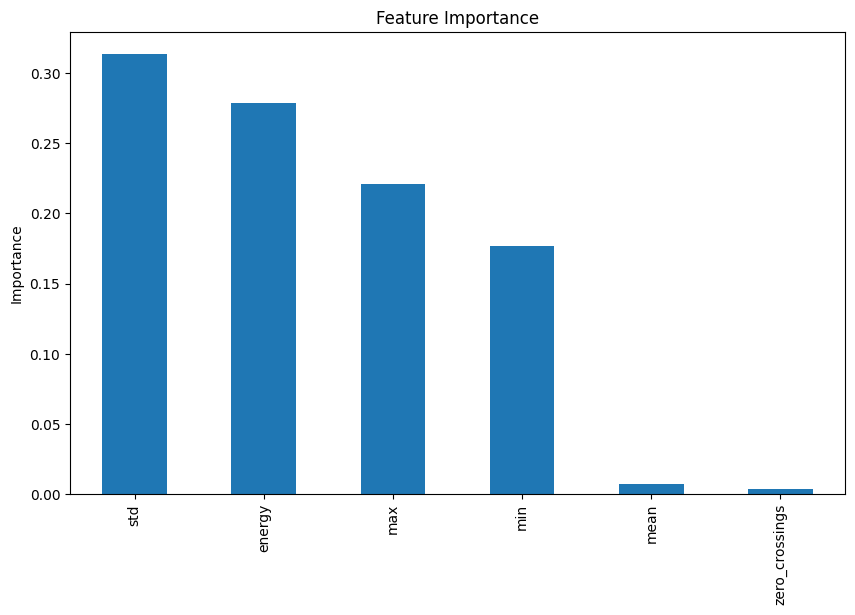

In [48]:
# Get feature importances
importances = model.feature_importances_

# Create a DataFrame for plotting
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

# Plot
feat_imp.plot(kind='bar', figsize=(10, 6))
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.show()


In [38]:
# Part 4: Apply to New Signal
new_ecg = nk.ecg_simulate(duration=10, noise=0.14, sampling_rate=200)
new_feat = pd.DataFrame([extract_features(new_ecg)])
prediction = model.predict(new_feat)
print("Predicted Class (0=Normal, 1=Abnormal):", prediction[0])


Predicted Class (0=Normal, 1=Abnormal): 1
